<a href="https://colab.research.google.com/github/Krishna-97/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Part 3: NLP and Sequence Modeling Mini Project**

## Task 1: Dataset Understanding

In [1]:
requirements_content = """
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.2.0
tensorflow>=2.12.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content.strip())

print("requirements.txt has been created!")

requirements.txt has been created!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_support_text_classification.csv')
print('---Dataset Info---')
print(df.info())


---Dataset Info---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   ticket_id         1500 non-null   object
 1   channel           1500 non-null   object
 2   customer_message  1500 non-null   object
 3   sentiment_label   1500 non-null   object
 4   word_count        1500 non-null   int64 
 5   urgent_flag       1500 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 70.4+ KB
None



---Target Labels---
['neutral' 'positive' 'negative']

---Sample Text Records----
                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neutral

Average_Text_Length (chars) : 72.76

---Class Distribution---
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


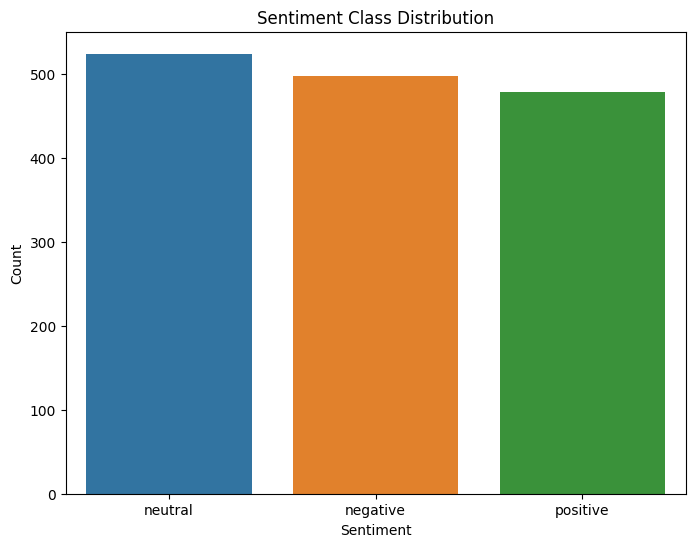

In [3]:
print('\n---Target Labels---')
print(df['sentiment_label'].unique())
print('\n---Sample Text Records----')
print(df[['customer_message','sentiment_label']].head())

avg_text_length = df['customer_message'].apply(len).mean()
print(f'\nAverage_Text_Length (chars) : {avg_text_length:.2f}')

class_dist = df['sentiment_label'].value_counts()
print('\n---Class Distribution---')
print(class_dist)

#Plot Class Distribution
plt.figure(figsize=(8,6))
sns.barplot(x=class_dist.index, y=class_dist.values,hue=class_dist.index)
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


## Task 2: Text Preprocessing

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import string

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    # Simple stopword list if nltk is not fully configured
    stop_words = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"])
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['clean_message'] = df['customer_message'].apply(clean_text)
print("\n--- Cleaned Text Sample ---")
print(df[['customer_message', 'clean_message']].head())


--- Cleaned Text Sample ---
                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                       clean_message  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


## Task 3 & 4: TF-IDF and Logistic Regression (Baseline)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

X = df['clean_message']
y = df['sentiment_label']

#Encode Labels
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
y_encoded = y.map(label_mapping)

#Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

tfidf = TfidfVectorizer(max_features=2000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("--- Baseline Model (Logistic Regression) Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=label_mapping.keys()))


--- Baseline Model (Logistic Regression) Evaluation ---
Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



## Task 5: Sequence Model (LSTM)

In [6]:
max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Build LSTM
lstm_model = Sequential([
    Embedding(max_words, 64, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(3, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train (few epochs for speed in this environment)
history = lstm_model.fit(X_train_pad, y_train, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test), verbose=0)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\n--- LSTM Model Evaluation ---")
print(f"Accuracy: {lstm_acc:.4f}")

# Save evaluation results
eval_results = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'LSTM (Sequences)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), lstm_acc]
})
eval_results.to_csv('model_evaluation.csv', index=False)

# Sample Predictions
sample_msgs = X_test.iloc[:5]
sample_preds_lr = lr_model.predict(X_test_tfidf[:5])
sample_preds_lstm = np.argmax(lstm_model.predict(X_test_pad[:5]), axis=1)

inv_label_mapping = {v: k for k, v in label_mapping.items()}

with open('sample_predictions.txt', 'w') as f:
    for i, msg in enumerate(sample_msgs):
        f.write(f"Message: {msg}\n")
        f.write(f"Actual: {inv_label_mapping[y_test.iloc[i]]}\n")
        f.write(f"LR Pred: {inv_label_mapping[sample_preds_lr[i]]}\n")
        f.write(f"LSTM Pred: {inv_label_mapping[sample_preds_lstm[i]]}\n")
        f.write("-" * 20 + "\n")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



--- LSTM Model Evaluation ---
Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


 ## Task 6: Attention and Transformer Reflection

1. **RNN Struggles:** Traditional RNNs suffer from the "vanishing gradient" problem. As sequences get longer, the model "forgets" the beginning of the sentence by the time it reaches the end.

2. **LSTMs to the Rescue:** LSTMs introduce "gates" (input, forget, and output gates) that allow the model to explicitly decide what information to keep or discard over time, preserving long-term  memory.

3. **Attention Mechanism:** Attention allows the model to look at all words in a sequence simultaneously and "focus" on the most relevant ones for a specific word, regardless of their distance.

4. **Transformers & GenAI:** Transformers replaced recurrence with Self-Attention. This allows for massive parallelization (unlike RNNs which are sequential) and captures complex global dependencies, forming the backbone of modern LLMs like GPT-4.





